In [23]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.linear_model import LinearRegression
import numpy as np

### Project

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   size        244 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 5.8 KB
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


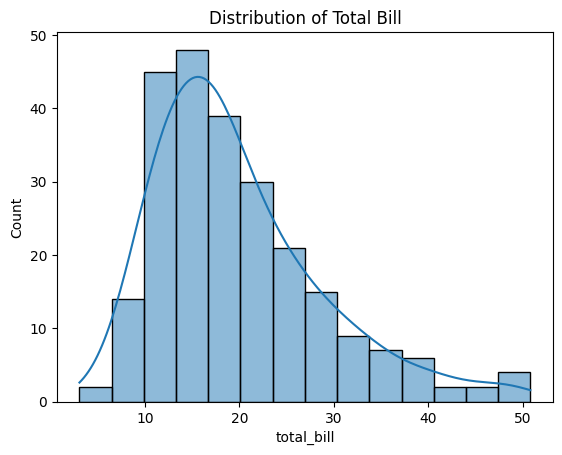

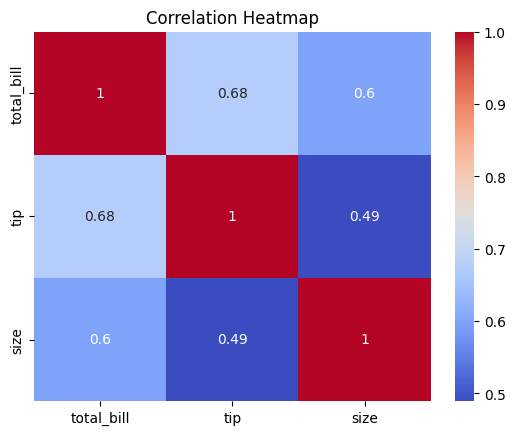

In [14]:
# Load Dataset
df = pd.read_csv(url)
del df['sex'] 
del df['smoker']
del df['day']
del df['time']

# Inspect the data
df.info()
print(df.describe())

# Visualize Distribution
sns.histplot(df['total_bill'], kde=True)
plt.title('Distribution of Total Bill')
plt.show()

# Correlation Heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [26]:
# Seperate data by gender
df = pd.read_csv(url)
male_tips = df[df['sex'] == 'Male']['tip']
female_tips = df[df['sex'] == 'Female']['tip']

# Create contingency table for smoker and time
contigency_table = pd.crosstab(df['smoker'], df['time'])

# Perform chi-square test
chi, p, dof, expected = chi2_contingency(contigency_table)
print(f"Chi-square statistic: {chi}")
print(f"P-value: {p}")

# Interpretation
alpha = 0.05
if p <= alpha:
    print("Chi-square result: Reject the null hypothesis: Variables are dependent.")
else:
    print("Chi-square result: Fail to reject the null hypothesis: Variable are independent.")

# Perform t-test
t_stat, p_value = ttest_ind(male_tips, female_tips)
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Interpretation
if p_value < alpha:
    print("T-test result: Reject the null hypothesis: There is a significant difference between male and female tips.")
else:
    print("T-test result: Fail to reject the null hypothesis: There is no significant difference between male and female tips.")

Chi-square statistic: 0.5053733928754354
P-value: 0.4771485672079724
Chi-square result: Fail to reject the null hypothesis: Variable are independent.
T-statistic: 1.387859705421269
P-value: 0.16645623503456755
T-test result: Fail to reject the null hypothesis: There is no significant difference between male and female tips.


Slope: 0.10502451738435337
Intercept: 0.9202696135546731
R-squared: 0.45661658635167657


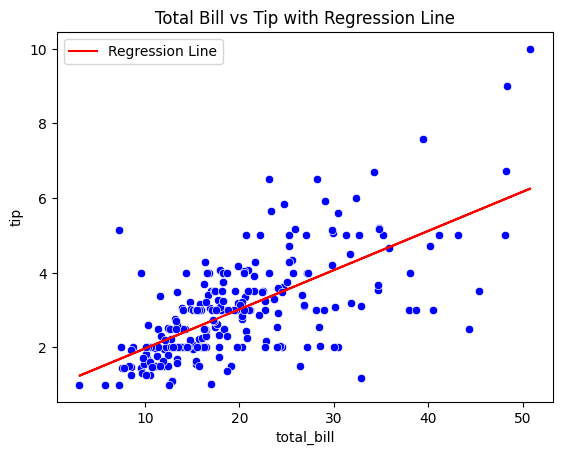

In [21]:
# Define Variables
X = df['total_bill'].values.reshape(-1, 1)  # Independent variable
y = df['tip'].values  # Dependent variable

# Fit Linear Regression Model
model = LinearRegression()
model.fit(X, y)

# Output Coefficients
print(f"Slope: {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")
print(f"R-squared: {model.score(X, y)}")

# Plotting the Regression Line
sns.scatterplot(x='total_bill', y='tip', color = 'blue', data=df)
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.title('Total Bill vs Tip with Regression Line')
plt.legend()
plt.show()

